In [ ]:
import os, sys, math, time, json, random, pickle
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

random.seed(0); np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

DATASET_ROOT   = Path("Dataset")           
CACHED_LABELS  = Path("crnn_plate") / "labels.csv"   
OUT_DIR        = Path("end_to_end_eval"); OUT_DIR.mkdir(exist_ok=True)

YOLO_POSE_WEIGHTS = "runs/pose/runs_plate_pose/final_model/weights/best.pt" 
CRNN_CKPT_PATH    = "crnn_plate/crnn_final.pt"                     
HEAD7_CKPT_PATH   = "runs_plate_recog/seven_warp/best.pt"                              
FRESH_SUBSET_SIZE  = 1500
MIN_PER_SUBSET     = 100
IMG_W, IMG_H       = 720, 1160               

LPRNET_CROP_H, LPRNET_CROP_W = 24, 94
HEAD7_CROP_H,  HEAD7_CROP_W  = 48, 168   

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("       ", torch.cuda.get_device_name(0))
print("CCPD root :", DATASET_ROOT.resolve(), "| exists:", DATASET_ROOT.exists())
print("Cache    :", CACHED_LABELS.resolve(), "| exists:", CACHED_LABELS.exists())

device: cuda
        NVIDIA GeForce RTX 2060
CCPD root : /home/luca/IS_Project/Dataset | exists: True
Cache    : /home/luca/IS_Project/crnn_plate/labels.csv | exists: True


In [19]:
PROVINCES = ['皖','沪','津','渝','冀','晋','蒙','辽','吉','黑','苏','浙','京',
             '闽','赣','鲁','豫','鄂','湘','粤','桂','琼','川','贵','云','藏',
             '陕','甘','青','宁','新','警','学','O']                                # 34
ALPHABETS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
             'P','Q','R','S','T','U','V','W','X','Y','Z','O']                       # 25
ADS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
       'P','Q','R','S','T','U','V','W','X','Y','Z',
       '0','1','2','3','4','5','6','7','8','9','O']                                 # 35

def parse_ccpd_filename(path):
    name = Path(path).stem
    f = name.split('-')
    if len(f) != 7: return None
    f_area, f_tilt, f_bbox, f_verts, f_label, f_bright, f_blur = f
    try:
        (x1,y1),(x2,y2) = [tuple(map(int,p.split('&'))) for p in f_bbox.split('_')]
        verts = [tuple(map(int,p.split('&'))) for p in f_verts.split('_')]
        if len(verts) != 4: return None
        idxs = list(map(int, f_label.split('_')))
        if len(idxs) != 7: return None
        plate = PROVINCES[idxs[0]] + ALPHABETS[idxs[1]] + ''.join(ADS[i] for i in idxs[2:])
    except (ValueError, IndexError):
        return None
    return {"path": str(path), "bbox": (x1,y1,x2,y2), "vertices": verts, "plate": plate}

def order_corners(pts):
    '''Sort 4 points into TL, TR, BR, BL.'''
    pts = np.asarray(pts, dtype=np.float32)
    s = pts.sum(axis=1); d = np.diff(pts, axis=1).ravel()
    return np.stack([pts[np.argmin(s)], pts[np.argmin(d)],
                     pts[np.argmax(s)], pts[np.argmax(d)]])

def discover_subset(p: Path) -> str:
    try:
        rel = p.relative_to(DATASET_ROOT); parts = rel.parts
        return parts[0] if len(parts) > 1 else "unknown"
    except ValueError:
        return "unknown"

# CRNN/LPRNet vocabulary (identical to what was used to train them)
REAL_PROVINCES = [p for p in PROVINCES if p != 'O']
REAL_LETTERS   = [a for a in ALPHABETS if a != 'O']
REAL_DIGITS    = [d for d in ADS if d.isdigit()]
VOCAB = ['<blank>'] + REAL_PROVINCES + REAL_LETTERS + REAL_DIGITS
CHAR2IDX = {c: i for i, c in enumerate(VOCAB)}
IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}
N_CLASSES = len(VOCAB); BLANK_IDX = 0
print(f"vocabulary: {N_CLASSES} classes (incl. blank)")

vocabulary: 68 classes (incl. blank)


In [ ]:
def gather_by_subset(root, excluded_stems: set):
    by = {}
    for p in root.rglob("*.jpg"):
        if p.stem in excluded_stems: continue
        by.setdefault(discover_subset(p), []).append(p)
    return by

def stratified_sample(by_subset, max_images, min_per_subset, seed=0):
    rng = random.Random(seed)
    subsets = {k: list(v) for k,v in by_subset.items()}
    for v in subsets.values(): rng.shuffle(v)
    total = sum(len(v) for v in subsets.values())
    if max_images is None or max_images >= total:
        return subsets
    alloc = {k: min(min_per_subset, len(v)) for k,v in subsets.items()}
    used = sum(alloc.values()); remaining = max_images - used
    if remaining > 0:
        leftover = {k: len(v)-alloc[k] for k,v in subsets.items()}
        lt = sum(leftover.values())
        if lt > 0:
            for k in subsets:
                add = int(round(remaining * leftover[k] / lt))
                alloc[k] = min(len(subsets[k]), alloc[k]+add)
    over = sum(alloc.values()) - max_images
    if over > 0:
        for k in sorted(alloc, key=lambda z: alloc[z], reverse=True):
            cut = min(over, alloc[k]-min(min_per_subset, len(subsets[k])))
            alloc[k] -= max(cut,0); over -= max(cut,0)
            if over <= 0: break
    return {k: subsets[k][:alloc[k]] for k in subsets}

excluded = set()
if CACHED_LABELS.exists():
    cached_df = pd.read_csv(CACHED_LABELS)
    excluded = set(Path(p).stem for p in cached_df["path"])
    print(f"Excluding {len(excluded):,} images previously used in any cache")
else:
    print("⚠ no cached labels.csv found — fresh subset will be drawn from the entire dataset")

by_subset = gather_by_subset(DATASET_ROOT, excluded)
print("\nAvailable (untouched) by subset:", {k: len(v) for k,v in by_subset.items()})

sampled = stratified_sample(by_subset, FRESH_SUBSET_SIZE, MIN_PER_SUBSET, seed=42)
fresh_paths = []
for subset, plist in sampled.items():
    for p in plist:
        fresh_paths.append({"path": str(p), "subset": subset, "stem": p.stem})
fresh_df = pd.DataFrame(fresh_paths)
print(f"\nFresh subset built: {len(fresh_df)} images")
print(fresh_df["subset"].value_counts().sort_index().to_string())

Excluding 7,715 images previously used in any cache

Available (untouched) by subset: {'ccpd_fn': 19975, 'ccpd_challenge': 48108, 'ccpd_weather': 9623, 'ccpd_blur': 19607, 'ccpd_np': 3036, 'ccpd_db': 9523, 'ccpd_rotate': 9522, 'ccpd_base': 196289, 'ccpd_tilt': 29126}

Fresh subset built: 1500 images
subset
ccpd_base         442
ccpd_blur         134
ccpd_challenge    184
ccpd_db           116
ccpd_fn           135
ccpd_np           105
ccpd_rotate       116
ccpd_tilt         151
ccpd_weather      117


In [21]:
rows = []
for _, r in fresh_df.iterrows():
    rec = parse_ccpd_filename(r["path"])
    if rec is None:
        rows.append({"path": r["path"], "subset": r["subset"], "plate": None,
                     "vertices_gt": None, "skipped": True})
        continue
    rows.append({"path": r["path"], "subset": r["subset"], "plate": rec["plate"],
                 "vertices_gt": rec["vertices"], "skipped": False})

fresh_df = pd.DataFrame(rows)
fresh_df = fresh_df[~fresh_df["skipped"]].reset_index(drop=True)
print(f"Fresh subset after parsing: {len(fresh_df)}")
print(fresh_df.head(3))

Fresh subset after parsing: 1395
                                                path   subset    plate  \
0  Dataset/ccpd_fn/0053-0_0-235&547_342&589-342&5...  ccpd_fn  皖AJ116B   
1  Dataset/ccpd_fn/0076-7_0-329&470_445&525-440&5...  ccpd_fn  皖A71W78   
2  Dataset/ccpd_fn/0733-0_0-94&459_548&594-548&58...  ccpd_fn  皖AJ291W   

                                        vertices_gt  skipped  
0  [(342, 588), (236, 589), (235, 548), (341, 547)]    False  
1  [(440, 525), (329, 510), (334, 470), (445, 485)]    False  
2    [(548, 587), (98, 594), (94, 466), (544, 459)]    False  


In [22]:
try:
    from ultralytics import YOLO
except ImportError:
    raise SystemExit("Install ultralytics: pip install ultralytics")

assert Path(YOLO_POSE_WEIGHTS).exists(), f"YOLO-pose weights not found at {YOLO_POSE_WEIGHTS}"
pose_model = YOLO(YOLO_POSE_WEIGHTS)
print(f"Loaded YOLO-pose model from {YOLO_POSE_WEIGHTS}")

predicted_corners = []   # one entry per fresh image; None if no detection
detection_conf    = []
t0 = time.time()

# Batch through ultralytics' .predict — it'll batch internally if you pass a list.
# For a clean per-image record we still loop, but predict() reuses GPU state.
paths = fresh_df["path"].tolist()
for i in range(0, len(paths), 32):
    batch = paths[i:i+32]
    results = pose_model.predict(batch, imgsz=640, device=DEVICE, verbose=False)
    for r in results:
        if r.keypoints is None or len(r.keypoints) == 0:
            predicted_corners.append(None); detection_conf.append(0.0)
            continue
        # Take the highest-confidence detection (CCPD has one plate per image)
        confs = r.boxes.conf.cpu().numpy() if r.boxes is not None and r.boxes.conf is not None else np.array([1.0])
        best_idx = int(np.argmax(confs))
        kp = r.keypoints.xy.cpu().numpy()[best_idx]    # (4, 2) — in original image coordinates
        predicted_corners.append(kp.tolist())
        detection_conf.append(float(confs[best_idx]))
    if (i+32) % 320 == 0 or i+32 >= len(paths):
        dt = time.time() - t0
        n = min(i+32, len(paths))
        print(f"  {n}/{len(paths)}  ({dt:.0f}s, {n/dt:.1f} img/s)")

fresh_df["corners_pred"] = predicted_corners
fresh_df["detection_conf"] = detection_conf

n_missed = (fresh_df["corners_pred"].isna()).sum()
print(f"\nPose miss rate: {n_missed}/{len(fresh_df)} = {n_missed/len(fresh_df):.4f}")
print(f"Pose detection mean confidence (on hits): {fresh_df.loc[fresh_df['corners_pred'].notna(), 'detection_conf'].mean():.3f}")

Loaded YOLO-pose model from runs/pose/runs_plate_pose/final_model/weights/best.pt
  320/1395  (4s, 90.3 img/s)
  640/1395  (7s, 91.0 img/s)
  960/1395  (10s, 91.9 img/s)
  1280/1395  (14s, 92.2 img/s)
  1395/1395  (15s, 92.1 img/s)

Pose miss rate: 0/1395 = 0.0000
Pose detection mean confidence (on hits): 0.861


In [23]:
def corner_error_px(gt_verts, pred_verts):
    '''Mean of per-corner Euclidean distances after ordering both into TL,TR,BR,BL.'''
    gt   = order_corners(gt_verts)
    pred = order_corners(pred_verts)
    return float(np.linalg.norm(gt - pred, axis=1).mean())

errors = []
for _, r in fresh_df.iterrows():
    if r["corners_pred"] is None:
        errors.append(None)
    else:
        errors.append(corner_error_px(r["vertices_gt"], r["corners_pred"]))
fresh_df["corner_err_px"] = errors

hits = fresh_df["corner_err_px"].dropna()
print(f"Corner localisation error (pixels), detected plates only:")
print(f"  mean   : {hits.mean():.2f} px")
print(f"  median : {hits.median():.2f} px")
print(f"  p90    : {hits.quantile(0.90):.2f} px")
print(f"  max    : {hits.max():.2f} px")

# Per-subset breakdown — the hard subsets (rotate/tilt) usually have larger errors
print("\nPer-subset corner error (median px):")
print(fresh_df.groupby("subset")["corner_err_px"].median().sort_values().to_string())

Corner localisation error (pixels), detected plates only:
  mean   : 5.36 px
  median : 3.64 px
  p90    : 9.06 px
  max    : 376.00 px

Per-subset corner error (median px):
subset
ccpd_base         2.888046
ccpd_challenge    3.207560
ccpd_weather      3.515503
ccpd_blur         3.959790
ccpd_rotate       4.437032
ccpd_tilt         5.486546
ccpd_fn           5.671732
ccpd_db           5.918715


In [24]:
def rectify_plate_bgr(img_bgr, vertices, out_w, out_h):
    corners = order_corners(vertices).astype(np.float32)
    dst = np.array([[0,0],[out_w-1,0],[out_w-1,out_h-1],[0,out_h-1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(corners, dst)
    return cv2.warpPerspective(img_bgr, M, (out_w, out_h))

# Pre-rectify two versions of each plate (one for LPRNet's 24×94, one for the 7-head CNN's 48×168).
# PaddleOCR is happy with either size; we'll feed it the LPRNet-sized crops to share.

CROPS_DIR_LPRNET = OUT_DIR / "crops_lprnet"; CROPS_DIR_LPRNET.mkdir(exist_ok=True)
CROPS_DIR_HEAD7  = OUT_DIR / "crops_head7";  CROPS_DIR_HEAD7.mkdir(exist_ok=True)

crop_paths_lprnet = []
crop_paths_head7  = []
for i, r in fresh_df.iterrows():
    if r["corners_pred"] is None:
        crop_paths_lprnet.append(None); crop_paths_head7.append(None); continue
    img = cv2.imread(r["path"])
    if img is None:
        crop_paths_lprnet.append(None); crop_paths_head7.append(None); continue
    try:
        crop_l = rectify_plate_bgr(img, r["corners_pred"], LPRNET_CROP_W, LPRNET_CROP_H)
        crop_h = rectify_plate_bgr(img, r["corners_pred"], HEAD7_CROP_W,  HEAD7_CROP_H)
    except Exception:
        crop_paths_lprnet.append(None); crop_paths_head7.append(None); continue
    stem = Path(r["path"]).stem
    p_l = CROPS_DIR_LPRNET / f"{stem}.jpg"; cv2.imwrite(str(p_l), crop_l); crop_paths_lprnet.append(str(p_l))
    p_h = CROPS_DIR_HEAD7  / f"{stem}.jpg"; cv2.imwrite(str(p_h), crop_h); crop_paths_head7.append(str(p_h))

fresh_df["crop_lprnet_path"] = crop_paths_lprnet
fresh_df["crop_head7_path"]  = crop_paths_head7

n_ok = fresh_df["crop_lprnet_path"].notna().sum()
print(f"Rectified crops written: {n_ok}/{len(fresh_df)} (failures = no pose detection or warp error)")

Rectified crops written: 1395/1395 (failures = no pose detection or warp error)


/tmp/ipykernel_624950/71738969.py:8: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


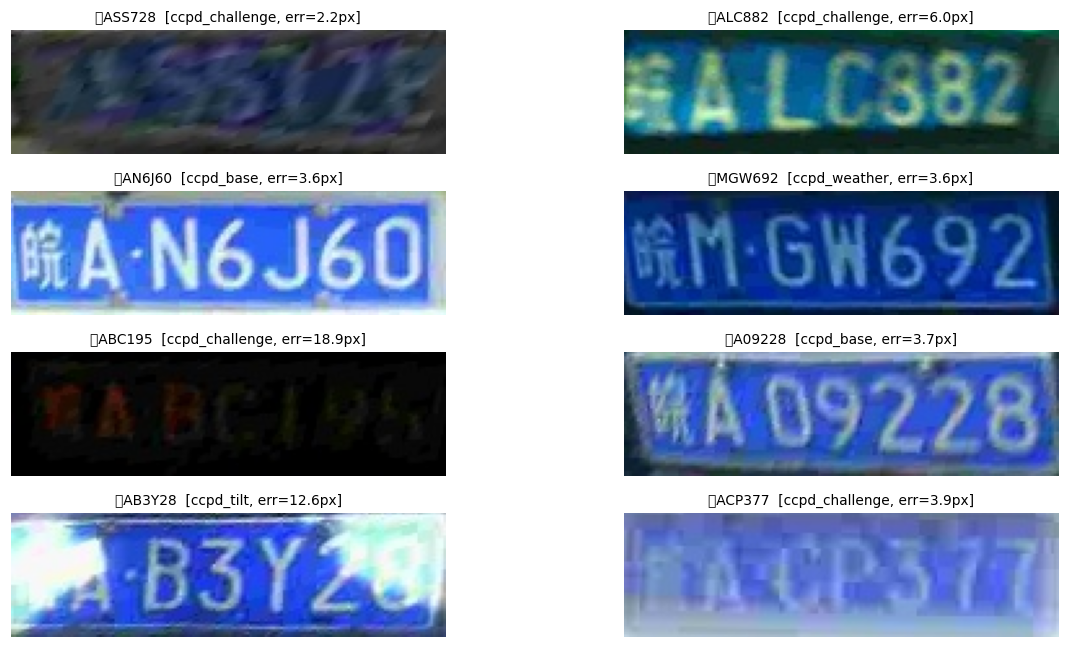

In [16]:
subset = fresh_df[fresh_df["crop_lprnet_path"].notna()].sample(8, random_state=0).reset_index(drop=True)
fig, axes = plt.subplots(4, 2, figsize=(12, 6))
for ax, (_, r) in zip(axes.ravel(), subset.iterrows()):
    img = cv2.imread(r["crop_head7_path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{r['plate']}  [{r['subset']}, err={r['corner_err_px']:.1f}px]", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [25]:
import torch.nn as nn
import torch.nn.functional as F

class small_basic_block(nn.Module):
    def __init__(self, ch_in, ch_out):
        super().__init__()
        ch_mid = ch_out // 4
        self.block = nn.Sequential(
            nn.Conv2d(ch_in,  ch_mid, kernel_size=1), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_mid, kernel_size=(3,1), padding=(1,0)), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_mid, kernel_size=(1,3), padding=(0,1)), nn.ReLU(),
            nn.Conv2d(ch_mid, ch_out, kernel_size=1),
        )
    def forward(self, x): return self.block(x)

class LPRNet(nn.Module):
    def __init__(self, class_num=N_CLASSES, dropout_rate=0.5):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=1),
            small_basic_block(64, 128), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=(1,2)),
            small_basic_block(128, 256), nn.BatchNorm2d(256), nn.ReLU(),
            small_basic_block(256, 256), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=(1,2)),
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, 256, kernel_size=(1,4), stride=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, class_num, kernel_size=(13,1)),
            nn.BatchNorm2d(class_num), nn.ReLU(),
        )
        self.container = nn.Conv2d(64+128+256+class_num, class_num, kernel_size=1)
    def forward(self, x):
        keep = {2, 6, 13, 22}
        feats = []
        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i in keep: feats.append(x)
        H_out, W_out = feats[-1].shape[2], feats[-1].shape[3]
        normed = []
        for f in feats:
            f_n = f.div(f.pow(2).mean().clamp(min=1e-8))
            if f.shape[2:] != (H_out, W_out):
                f_n = F.adaptive_avg_pool2d(f_n, (H_out, W_out))
            normed.append(f_n)
        cat = torch.cat(normed, dim=1)
        logits = self.container(cat).mean(dim=2)         # B x V x W
        return logits.permute(2, 0, 1).contiguous()       # T x B x V

def greedy_ctc_decode(logits_TBV):
    idx = logits_TBV.argmax(dim=2).cpu().numpy()
    T, B = idx.shape
    out = []
    for b in range(B):
        seq = []; prev = -1
        for t in range(T):
            c = int(idx[t, b])
            if c != prev and c != BLANK_IDX:
                seq.append(IDX2CHAR[c])
            prev = c
        out.append(''.join(seq))
    return out

def to_lprnet_tensor(img_bgr):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    if img.shape[:2] != (LPRNET_CROP_H, LPRNET_CROP_W):
        img = cv2.resize(img, (LPRNET_CROP_W, LPRNET_CROP_H))
    x = (img.astype(np.float32) / 255.0 - 0.5) / 0.5
    return torch.from_numpy(x).permute(2, 0, 1)

# Load checkpoint
if Path(CRNN_CKPT_PATH).exists():
    lprnet = LPRNet(N_CLASSES).to(DEVICE)
    ckpt = torch.load(CRNN_CKPT_PATH, map_location=DEVICE)
    state = ckpt.get("model_state_dict", ckpt)   # handle wrapped or raw state-dict
    lprnet.load_state_dict(state)
    lprnet.eval()
    print(f"Loaded LPRNet from {CRNN_CKPT_PATH}")

    # Run inference
    preds_lprnet = []
    BATCH = 64
    rows_with_crop = fresh_df[fresh_df["crop_lprnet_path"].notna()].reset_index(drop=True)
    t0 = time.time()
    for i in range(0, len(rows_with_crop), BATCH):
        batch = rows_with_crop.iloc[i:i+BATCH]
        xs = []
        for _, r in batch.iterrows():
            img = cv2.imread(r["crop_lprnet_path"])
            xs.append(to_lprnet_tensor(img))
        xb = torch.stack(xs).to(DEVICE)
        with torch.no_grad():
            logits = lprnet(xb)
        preds_lprnet.extend(greedy_ctc_decode(logits))
    print(f"LPRNet inference: {len(preds_lprnet)} preds in {time.time()-t0:.1f}s")

    # Map back to fresh_df (None for images with no pose detection)
    pred_map = dict(zip(rows_with_crop["path"], preds_lprnet))
    fresh_df["pred_lprnet"] = fresh_df["path"].map(pred_map)
else:
    print(f"⚠ LPRNet checkpoint not found at {CRNN_CKPT_PATH} — skipping this recogniser")
    fresh_df["pred_lprnet"] = None

Loaded LPRNet from crnn_plate/crnn_final.pt
LPRNet inference: 1395 preds in 0.8s


In [ ]:
class SevenHeadCNN(nn.Module):
    def __init__(self, n_prov=len(REAL_PROVINCES), n_letter=len(REAL_LETTERS),
                 n_alnum=len(REAL_LETTERS)+len(REAL_DIGITS)):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        # Seven heads — one per character position
        self.head_p1 = nn.Linear(256, n_prov)
        self.head_p2 = nn.Linear(256, n_letter)
        self.heads_p3_7 = nn.ModuleList([nn.Linear(256, n_alnum) for _ in range(5)])

    def forward(self, x):
        f = self.backbone(x)
        return [self.head_p1(f), self.head_p2(f)] + [h(f) for h in self.heads_p3_7]

def decode_head7(logits_list):
    '''Decode the 7 head outputs into plate strings. logits_list = list of 7 tensors (B, n_classes_i).'''
    B = logits_list[0].shape[0]
    out = []
    p3_7_charset = REAL_LETTERS + REAL_DIGITS
    for b in range(B):
        s = REAL_PROVINCES[int(logits_list[0][b].argmax())]
        s += REAL_LETTERS[int(logits_list[1][b].argmax())]
        for k in range(5):
            s += p3_7_charset[int(logits_list[2+k][b].argmax())]
        out.append(s)
    return out

def to_head7_tensor(img_bgr):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    if img.shape[:2] != (HEAD7_CROP_H, HEAD7_CROP_W):
        img = cv2.resize(img, (HEAD7_CROP_W, HEAD7_CROP_H))
    x = (img.astype(np.float32) / 255.0 - 0.5) / 0.5
    return torch.from_numpy(x).permute(2, 0, 1)

if Path(HEAD7_CKPT_PATH).exists():
    head7 = SevenHeadCNN().to(DEVICE)
    ckpt = torch.load(HEAD7_CKPT_PATH, map_location=DEVICE)
    state = ckpt.get("model_state_dict", ckpt)
    try:
        head7.load_state_dict(state)
        loaded_ok = True
        print(f"Loaded 7-head CNN from {HEAD7_CKPT_PATH}")
    except RuntimeError as e:
        print("⚠ checkpoint shapes don't match the SevenHeadCNN placeholder above.")
        print("  Replace the SevenHeadCNN class with your actual architecture and re-run this cell.")
        print(f"  PyTorch error: {e}")
        loaded_ok = False

    if loaded_ok:
        head7.eval()
        preds_head7 = []
        rows_with_crop = fresh_df[fresh_df["crop_head7_path"].notna()].reset_index(drop=True)
        BATCH = 64
        t0 = time.time()
        for i in range(0, len(rows_with_crop), BATCH):
            batch = rows_with_crop.iloc[i:i+BATCH]
            xs = []
            for _, r in batch.iterrows():
                img = cv2.imread(r["crop_head7_path"])
                xs.append(to_head7_tensor(img))
            xb = torch.stack(xs).to(DEVICE)
            with torch.no_grad():
                logits_list = head7(xb)
            preds_head7.extend(decode_head7(logits_list))
        print(f"7-head CNN inference: {len(preds_head7)} preds in {time.time()-t0:.1f}s")
        pred_map = dict(zip(rows_with_crop["path"], preds_head7))
        fresh_df["pred_head7"] = fresh_df["path"].map(pred_map)
    else:
        fresh_df["pred_head7"] = None
else:
    print(f"⚠ 7-head CNN checkpoint not found at {HEAD7_CKPT_PATH} — skipping this recogniser")
    fresh_df["pred_head7"] = None

⚠ checkpoint shapes don't match the SevenHeadCNN placeholder above.
  Replace the SevenHeadCNN class with your actual architecture and re-run this cell.
  PyTorch error: Error(s) in loading state_dict for SevenHeadCNN:
	Missing key(s) in state_dict: "backbone.0.weight", "backbone.0.bias", "backbone.1.weight", "backbone.1.bias", "backbone.1.running_mean", "backbone.1.running_var", "backbone.4.weight", "backbone.4.bias", "backbone.5.weight", "backbone.5.bias", "backbone.5.running_mean", "backbone.5.running_var", "backbone.8.weight", "backbone.8.bias", "backbone.9.weight", "backbone.9.bias", "backbone.9.running_mean", "backbone.9.running_var", "backbone.12.weight", "backbone.12.bias", "backbone.13.weight", "backbone.13.bias", "backbone.13.running_mean", "backbone.13.running_var", "head_p1.weight", "head_p1.bias", "head_p2.weight", "head_p2.bias", "heads_p3_7.0.weight", "heads_p3_7.0.bias", "heads_p3_7.1.weight", "heads_p3_7.1.bias", "heads_p3_7.2.weight", "heads_p3_7.2.bias", "heads_p3_7.

In [27]:
try:
    from paddleocr import TextRecognition
    paddle_available = True
except ImportError:
    print("⚠ PaddleOCR not installed in this env. Skip this section or switch to your paddle venv.")
    paddle_available = False

def extract_text_and_score(res):
    if res is None: return "", 0.0
    for txt_key, sc_key in [("rec_text","rec_score"), ("text","score")]:
        if hasattr(res, "json"):
            try:
                d = res.json
                if isinstance(d, dict) and txt_key in d:
                    return str(d[txt_key]), float(d.get(sc_key, 0.0))
            except Exception: pass
        if hasattr(res, "get") and res.get(txt_key) is not None:
            return str(res[txt_key]), float(res.get(sc_key, 0.0))
        if hasattr(res, txt_key):
            return str(getattr(res, txt_key)), float(getattr(res, sc_key, 0.0))
    if isinstance(res, (tuple, list)) and len(res) >= 2:
        try: return str(res[0]), float(res[1])
        except Exception: pass
    return "", 0.0

VALID_LETTERS = set(REAL_LETTERS)
VALID_DIGITS  = set(REAL_DIGITS)
VALID_PROVS   = set(REAL_PROVINCES)
def clean_prediction(raw):
    if raw is None: return ""
    s = str(raw).strip().upper()
    s = "".join(c for c in s if not c.isspace() and c not in ".,-•·")
    all_valid = VALID_LETTERS | VALID_DIGITS | VALID_PROVS
    s = "".join(c for c in s if c in all_valid)
    return s[:7]

if paddle_available:
    recognizer = TextRecognition(model_name="PP-OCRv5_server_rec")
    rows_with_crop = fresh_df[fresh_df["crop_head7_path"].notna()].reset_index(drop=True)
    crop_paths = rows_with_crop["crop_head7_path"].tolist()
    BATCH = 16
    raw_preds = []
    t0 = time.time()
    for i in range(0, len(crop_paths), BATCH):
        batch = crop_paths[i:i+BATCH]
        outs = recognizer.predict(input=batch, batch_size=len(batch))
        for res in outs:
            raw, _ = extract_text_and_score(res)
            raw_preds.append(clean_prediction(raw))
    print(f"PaddleOCR inference: {len(raw_preds)} preds in {time.time()-t0:.1f}s")
    pred_map = dict(zip(rows_with_crop["path"], raw_preds))
    fresh_df["pred_paddle"] = fresh_df["path"].map(pred_map)
else:
    fresh_df["pred_paddle"] = None

which: no ccache in (/home/luca/.venv-paddle/bin:/home/luca/gcc-arm-none-eabi-9-2020-q2-update/bin:/usr/local/sbin:/usr/local/bin:/usr/bin:/usr/lib/jvm/default/bin:/usr/bin/site_perl:/usr/bin/vendor_perl:/usr/bin/core_perl:/home/luca/.local/bin)
/home/luca/.venv-paddle/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/luca/.paddlex/official_models/PP-OCRv5_server_rec`.


PaddleOCR inference: 1395 preds in 7.6s


In [28]:
def evaluate_recogniser(df, pred_col):
    if df[pred_col].isna().all():
        return None
    # End-to-end: pred_col is None → miss → wrong; otherwise compare to truth
    full = (df[pred_col].fillna("") == df["plate"]).sum()
    n = len(df)
    # Conditional on detection
    detected = df[df["corners_pred"].notna() & df[pred_col].notna()]
    full_cond = (detected[pred_col] == detected["plate"]).sum()
    n_cond = len(detected)
    # Per-subset (end-to-end)
    per_subset = (df.assign(correct=df[pred_col].fillna("") == df["plate"])
                    .groupby("subset")["correct"].agg(["mean","sum","count"])
                    .rename(columns={"mean":"e2e_acc","sum":"correct","count":"n"})
                    .sort_values("e2e_acc", ascending=False))
    return {
        "e2e_full_plate_acc"   : full / max(n, 1),
        "n_e2e"                : n,
        "cond_full_plate_acc"  : full_cond / max(n_cond, 1) if n_cond else 0,
        "n_cond"               : n_cond,
        "per_subset"           : per_subset,
    }

summaries = {}
for label, col in [("LPRNet", "pred_lprnet"),
                   ("7-head CNN", "pred_head7"),
                   ("PaddleOCR (zero-shot)", "pred_paddle")]:
    s = evaluate_recogniser(fresh_df, col)
    summaries[label] = s

# Headline table
print("="*70)
print("END-TO-END EVALUATION  (YOLO-pose → rectify → recogniser)")
print("="*70)
print(f"\nFresh subset:                 {len(fresh_df)} images")
print(f"YOLO-pose miss rate:          {fresh_df['corners_pred'].isna().sum()}/{len(fresh_df)}"
      f" = {fresh_df['corners_pred'].isna().mean():.4f}")
hits = fresh_df['corner_err_px'].dropna()
print(f"Corner localisation (median): {hits.median():.2f} px (on detected plates)")

print(f"\n{'Recogniser':<25} {'E2E full-plate':>16} {'cond. on detect':>18}  {'n':>6}")
print("-"*72)
for label, s in summaries.items():
    if s is None:
        print(f"{label:<25} {'(skipped)':>16}"); continue
    print(f"{label:<25} {s['e2e_full_plate_acc']:>16.4f} {s['cond_full_plate_acc']:>18.4f}  {s['n_e2e']:>6}")

END-TO-END EVALUATION  (YOLO-pose → rectify → recogniser)

Fresh subset:                 1395 images
YOLO-pose miss rate:          0/1395 = 0.0000
Corner localisation (median): 3.64 px (on detected plates)

Recogniser                  E2E full-plate    cond. on detect       n
------------------------------------------------------------------------
LPRNet                              0.8158             0.8158    1395
7-head CNN                       (skipped)
PaddleOCR (zero-shot)               0.6459             0.6459    1395


In [29]:
# Combine per-subset accuracies into one wide table
combined = None
for label, s in summaries.items():
    if s is None: continue
    sub = s["per_subset"]["e2e_acc"].rename(label).to_frame()
    combined = sub if combined is None else combined.join(sub, how="outer")
# Add count column for reference
combined["n"] = next(s for s in summaries.values() if s is not None)["per_subset"]["n"]
combined = combined[["n"] + [c for c in combined.columns if c != "n"]]
display(combined.round(4))

,n,LPRNet,PaddleOCR (zero-shot)
subset,,,
ccpd_base,442,0.9864,0.9140
ccpd_blur,134,0.5448,0.1119
ccpd_challenge,184,0.7065,0.3859
ccpd_db,116,0.5948,0.3879
ccpd_fn,135,0.7037,0.5481
ccpd_rotate,116,0.8534,0.8103
ccpd_tilt,151,0.8212,0.6623
ccpd_weather,117,0.9573,0.8376


In [30]:
# These are the rectified-crop numbers from the recognition notebooks.
# Fill in whatever you actually measured on the frozen test set there.
RECTIFIED_CROP_BASELINE = {
    "LPRNet":               None,    # e.g. 0.85 — fill from crnn_recognition.ipynb section 11
    "7-head CNN":           0.50,    # the ~0.5 number you reported earlier
    "PaddleOCR (zero-shot)": None,   # fill from paddleocr_baseline.ipynb section 7
}

print("End-to-end gap (rectified-crop acc → end-to-end acc):")
print(f"{'Recogniser':<25} {'rect. crop':>12} {'end-to-end':>12} {'gap':>10}")
print("-"*65)
for label, s in summaries.items():
    if s is None: continue
    rect = RECTIFIED_CROP_BASELINE.get(label)
    e2e  = s["e2e_full_plate_acc"]
    if rect is None:
        print(f"{label:<25} {'(fill in)':>12} {e2e:>12.4f} {'?':>10}")
    else:
        gap = rect - e2e
        print(f"{label:<25} {rect:>12.4f} {e2e:>12.4f} {gap:>+10.4f}")

End-to-end gap (rectified-crop acc → end-to-end acc):
Recogniser                  rect. crop   end-to-end        gap
-----------------------------------------------------------------
LPRNet                       (fill in)       0.8158          ?
PaddleOCR (zero-shot)        (fill in)       0.6459          ?


/tmp/ipykernel_624950/1574988371.py:17: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


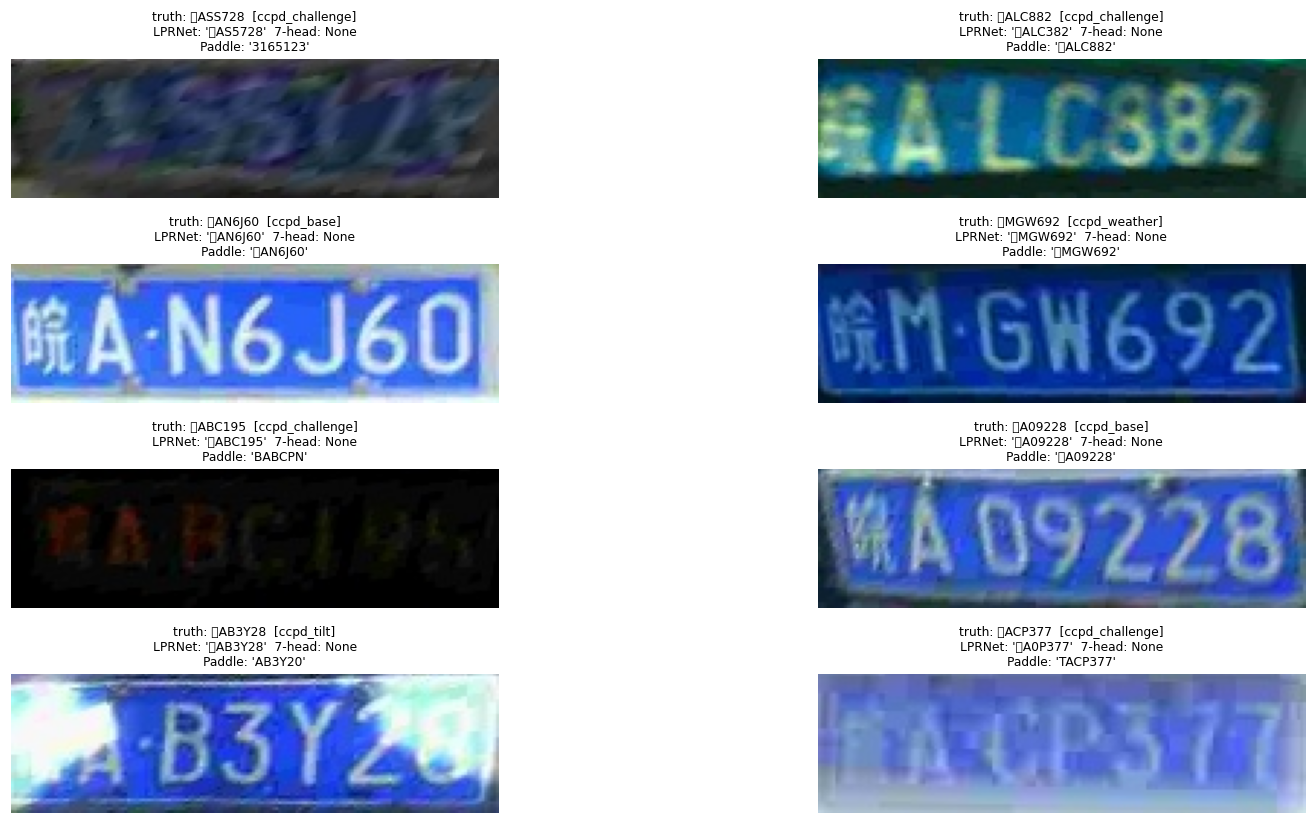

In [31]:
sample = fresh_df.sample(min(8, len(fresh_df)), random_state=0).reset_index(drop=True)
cols, rows = 2, math.ceil(len(sample) / 2)
fig, axes = plt.subplots(rows, cols, figsize=(cols*8, rows*1.9))
axes = np.array(axes).reshape(-1)
for ax, (_, r) in zip(axes, sample.iterrows()):
    path = r["crop_head7_path"] or r["path"]
    img = cv2.imread(path)
    if img is None: ax.axis("off"); continue
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    title = (f"truth: {r['plate']}  [{r['subset']}]\n"
             f"LPRNet: {r.get('pred_lprnet')!r}  "
             f"7-head: {r.get('pred_head7')!r}\n"
             f"Paddle: {r.get('pred_paddle')!r}")
    ax.set_title(title, fontsize=8)
    ax.axis("off")
for ax in axes[len(sample):]: ax.axis("off")
plt.tight_layout(); plt.show()

## 16. Save everything for the paper

In [ ]:
# Per-image predictions
fresh_df.to_csv(OUT_DIR / "e2e_predictions.csv", index=False)

# Summary JSON
def _to_serializable(o):
    if isinstance(o, pd.DataFrame):
        return o.reset_index().to_dict(orient="records")
    return o

summary_out = {
    "fresh_subset_size": int(len(fresh_df)),
    "pose_miss_rate":    float(fresh_df["corners_pred"].isna().mean()),
    "corner_err_median_px": float(fresh_df["corner_err_px"].dropna().median()),
    "corner_err_mean_px":   float(fresh_df["corner_err_px"].dropna().mean()),
    "recognisers": {
        label: {
            "e2e_full_plate_acc":  s["e2e_full_plate_acc"],
            "cond_full_plate_acc": s["cond_full_plate_acc"],
            "per_subset":          _to_serializable(s["per_subset"]),
        } for label, s in summaries.items() if s is not None
    },
}
with open(OUT_DIR / "e2e_summary.json", "w") as f:
    json.dump(summary_out, f, indent=2, ensure_ascii=False)
print(f"Saved:")
print(f"  {OUT_DIR/'e2e_predictions.csv'}  ({len(fresh_df)} rows)")
print(f"  {OUT_DIR/'e2e_summary.json'}")